Тема: Метод лінійної регресії в задачах системного аналізу даних.

Завдання 1. У межах обчислювального графа бібліотеки TensorFlow виконайте обчислення звичайних математичних операцій, зокрема тригонометричних і експоненціальних функцій на базі введених користувачем констант.

In [19]:
import tensorflow.compat.v1 as tf
import numpy as np

hello = tf.constant('Hello world!')

In [20]:
sess = tf.Session()

result = sess.run(hello)

print(result)


b'Hello world!'


In [21]:
with tf.Session() as sess:
    result = sess.run(hello)
    print(result)

b'Hello world!'


In [27]:
a = tf.constant(2, dtype=tf.float32)
b = tf.constant(3, dtype=tf.float32)

c = tf.constant([1, 2, 3, 4], dtype=tf.float32)
d = tf.constant([2, 3, 4, 5], dtype=tf.float32)

In [28]:
with tf.Session() as sess:
    print('a = {}, b = {}, c = {}, d = {}'.format(
          sess.run(a), sess.run(b),
          sess.run(c), sess.run(d)
    ))

    print('a + b = {}\n'
    'a * b = {}'.format(sess.run(a + b), sess.run(a * b)))

    print('c + d = {}\n'
    'c * d = {}'.format(sess.run(c + d), sess.run(c * d)))


a = 2.0, b = 3.0, c = [1. 2. 3. 4.], d = [2. 3. 4. 5.]
a + b = 5.0
a * b = 6.0
c + d = [3. 5. 7. 9.]
c * d = [ 2.  6. 12. 20.]


In [29]:
a = tf.placeholder(tf.int16)
b = tf.placeholder(tf.int16)

add = tf.add(a, b)
mul = tf.multiply(a, b)

with tf.Session() as sess:
    writer = tf.summary.FileWriter('logs', sess.graph)
    # > tensorboard --logdir logs/

    print('a + b = {}'.format(sess.run(add, feed_dict={a: 3, b: 1})))
    print('a * b = {}'.format(sess.run(mul, feed_dict={a: 7, b: 8})))


a + b = 4
a * b = 56


In [35]:
tf.disable_v2_behavior()

# Введення констант із правильним типом даних (float32)
a = tf.constant(2.0, dtype=tf.float32)
b = tf.constant(3.0, dtype=tf.float32)

c = tf.constant([1.0, 2.0, 3.0, 4.0], dtype=tf.float32)
d = tf.constant([2.0, 3.0, 4.0, 5.0], dtype=tf.float32)

# Математичні операції
sub = tf.subtract(a, b)
div = tf.divide(a, b)

# Тригонометричні функції
sin_a = tf.sin(a)
cos_a = tf.cos(a)
tan_a = tf.tan(a)

# Експоненціальні функції
exp_a = tf.exp(a)
log_a = tf.log(a)

# Запуск сесії
with tf.Session() as sess:
    print('Константи:')
    print(f'a = {sess.run(a)}, b = {sess.run(b)}')
    print(f'c = {sess.run(c)}, d = {sess.run(d)}\n')

    print('Математичні операції:')
    print(f'a - b = {sess.run(sub)}')
    print(f'a / b = {sess.run(div)}\n')

    print('Тригонометричні функції:')
    print(f'sin(a) = {sess.run(sin_a)}')
    print(f'cos(a) = {sess.run(cos_a)}')
    print(f'tan(a) = {sess.run(tan_a)}\n')

    print('Експоненціальні функції:')
    print(f'exp(a) = {sess.run(exp_a)}')
    print(f'log(a) = {sess.run(log_a)}')  # Натуральний логарифм (ln)

Константи:
a = 2.0, b = 3.0
c = [1. 2. 3. 4.], d = [2. 3. 4. 5.]

Математичні операції:
a - b = -1.0
a / b = 0.6666666865348816

Тригонометричні функції:
sin(a) = 0.9092974066734314
cos(a) = -0.416146844625473
tan(a) = -2.185039758682251

Експоненціальні функції:
exp(a) = 7.389056205749512
log(a) = 0.6931471824645996


Завдання 2. Для набору даних, які за умовчанням знаходяться в датасеті бібліотеки sklearn застосуйте методи і засоби штучного інтелекту для визначення лінійної функції задачі регресійного аналізу даних. Проаналізуйте побудований графік лінійної регресійної функції на основі представлених даних.

In [36]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from sklearn.datasets import make_regression

n_samples = 42

x_train, y_train = make_regression(
    n_samples=n_samples, n_features=1,
    noise=15, random_state=7
)
x_train = (x_train - x_train.mean()) / x_train.std()
y_train = (y_train - y_train.mean()) / y_train.std()

In [37]:
print(x_train[:5])

[[ 0.03264883]
 [ 2.00453732]
 [-0.09529635]
 [-0.29220736]
 [ 0.19354651]]


In [40]:
X = tf.placeholder('float')
Y = tf.placeholder('float')

W = tf.Variable(np.random.randn(), name='weight')
b = tf.Variable(np.random.randn(), name='bias')

prediction = tf.add(tf.multiply(X, W), b)

learning_rate = tf.placeholder(tf.float32, shape=[])

cost = tf.reduce_sum(tf.pow(prediction - Y, 2)) / n_samples
optimizer = tf.train.GradientDescentOptimizer(learning_rate).minimize(cost)


In [41]:
init = tf.global_variables_initializer()

In [42]:
epochs = 1000
sess = tf.Session()
sess.run(init)

lr = 0.1
for epoch in range(epochs):
    for (x_batch, y_batch) in zip(x_train, y_train):
        sess.run(optimizer, feed_dict={X: x_batch, Y: y_batch, learning_rate: lr})
    
    if epoch % 100 == 0:
        lr /= 2
        c = sess.run(cost, feed_dict={X: x_train, Y: y_train})
        print('Epoch #{}: cost = {}'.format(epoch, c))
                                      


Epoch #0: cost = 56.02518844604492
Epoch #100: cost = 67.63412475585938
Epoch #200: cost = 67.46204376220703
Epoch #300: cost = 67.38156127929688
Epoch #400: cost = 67.34587097167969
Epoch #500: cost = 67.32942199707031
Epoch #600: cost = 67.32154083251953
Epoch #700: cost = 67.31765747070312
Epoch #800: cost = 67.31454467773438
Epoch #900: cost = 67.31415557861328


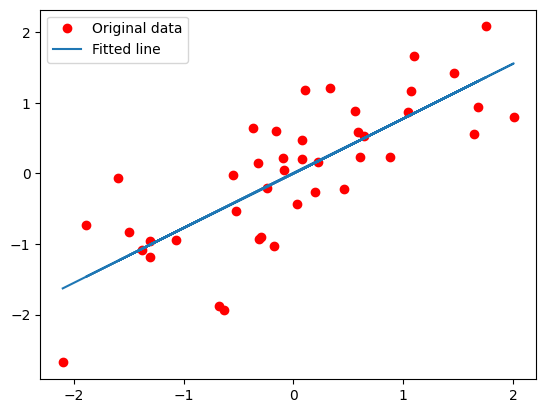

In [43]:
plt.plot(x_train, y_train, 'ro', label='Original data')
plt.plot(x_train, sess.run(W) * x_train + sess.run(b), label='Fitted line')
plt.legend()
plt.show()

Вхідні дані (червоні точки) - Це вихідні дані, які є випадковими точками, згенерованими за допомогою make_regression(), але з додаванням шуму (noise=15).
Наближена лінія (синя лінія) - Це регресійна лінія, отримана за допомогою градієнтного спуску, вона наближена до загального тренду вихідних даних, що свідчить про правильну роботу моделі.
Оцінка результату - Лінія добре вписується у розподіл точок, хоча деякі точки знаходяться далеко через наявність шуму та Зменшення навчальної швидкості (lr /= 2 кожні 100 епох) допомагає стабілізувати процес навчання.